# Cash Flow & Estimate-at-Completion Scenarios

**Atul Iwale · AEC Intelligence Portfolio · executed synthetic-data walkthrough**

> **Decision:** How sensitive are completion cost and funding needs to cost pressure and receipt timing?

[Case study](https://github.com/AtulIwale/Portfolio/tree/main/projects/04-cash-eac) ·
[Data assumptions](https://github.com/AtulIwale/Portfolio/blob/main/docs/DATA_CARD.md) ·
[Portfolio](https://github.com/AtulIwale/Portfolio)

Read the narrative, tables and saved charts on GitHub; no installation is required to read.
To reproduce, use **Runtime → Run all** in a fresh Colab session. The first cell downloads
the public repository and installs dependencies only in Colab. Locally, install
`requirements-notebooks.txt` and open this notebook from the repository.

All data is fictional. Results demonstrate an analytical approach, not proven client impact.

## 1. Reproducible setup

The notebook verifies the dataset hashes and imports reusable project functions. The
important decisions and calculations remain visible below. Saved outputs were produced
by executing all cells in a fresh Python process with IPython rich output capture.
Local Jupyter kernel sockets were unavailable; the hosted Colab service was not used for validation.

In [1]:
from pathlib import Path
import os, sys, subprocess, tempfile

# Pin the computational source/data so later edits to main do not change this walkthrough.
SOURCE_REV = "363f7edcd6c2357bc167257fce4e36b771b216d6"
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "aec/features.py").exists()), None)
if ROOT is None:
    ROOT = Path(tempfile.mkdtemp(prefix="aec-portfolio-")) / "Portfolio"
    subprocess.run(["git", "clone", "--quiet", "https://github.com/AtulIwale/Portfolio.git", str(ROOT)], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "--quiet", SOURCE_REV], check=True)
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-r", str(ROOT / "requirements.txt"), "matplotlib==3.10.8"], check=True)
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
os.environ.setdefault("OMP_NUM_THREADS", "2")
print("Source:", SOURCE_REV if IN_COLAB else "local checkout")
print("Data: synthetic only; no client information or credentials required.")

Source: local checkout
Data: synthetic only; no client information or credentials required.


In [2]:
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aec.data import load_dataset

tables = load_dataset(ROOT / "data")
manifest = json.loads((ROOT / "data/manifest.json").read_text())
for name, spec in manifest["tables"].items():
    assert hashlib.sha256((ROOT / f"data/{name}.jsonl").read_bytes()).hexdigest() == spec["sha256"], name
plt.rcParams.update({"figure.figsize": (10, 4.8), "figure.dpi": 120,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": "#2D4653", "text.color": "#2D4653", "axes.titleweight": "bold",
    "axes.prop_cycle": plt.cycler(color=["#3F7285", "#B6A78E", "#2D4653", "#899BA5"])})
FIGURES = ROOT / "outputs/notebook-figures"
FIGURES.mkdir(parents=True, exist_ok=True)
def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=140, bbox_inches="tight", facecolor="white")
    plt.show()
print(f"Verified {len(tables)} tables / {sum(len(t) for t in tables.values()):,} synthetic rows against manifest hashes.")

Verified 12 tables / 28,682 synthetic rows against manifest hashes.


## 2. Separate observations from assumptions

This is a scenario simulator, not a fitted forecasting model. Physical progress, remaining
scope and customer receipt terms are explicit fictional extensions. They are not claimed
to be available from the documented registers. Actual cost is assumed already paid.

I choose the latest 50% snapshot without using its final-cost label. A fixed snapshot makes
scenario comparisons reproducible; it does not represent a typical project.

In [3]:
from aec.features import cost_features
from aec.analytics import scenario
f = cost_features(tables)
row = f.sort_values("snapshot_date").iloc[-1]
inputs = row[["package_id","snapshot_date","original_budget","progress_assumption","actual_cost","pending_variations"]]
display(inputs.to_frame("Scenario input"))

,Scenario input
package_id,WP00748
snapshot_date,2025-08-08 00:00:00
original_budget,3908450.12
progress_assumption,0.5
actual_cost,2227405.33
pending_variations,0.0


## 3. Make the cash and cost logic explicit

Remaining base cost = original budget × (1 − assumed progress).
EAC = incurred cost + simulated remaining cost + accepted pending variations.

A shared escalation shock affects all remaining months. Pending variations are accepted
as one package-level event with assumed probability 60%. Payment/receipt timing changes
funding needs; it does not directly change completion cost. Existing commitments are not
added again on top of remaining cost.

Five thousand draws use seed 42. P10/P50/P90 are **scenario quantiles**, not validated forecast
confidence intervals. These distributions and correlations need business-owner challenge.

In [4]:
settings={"Base":(.06,2),"Cost stress":(.18,2),"Receipt delay":(.06,4)}
results={name:scenario(row.to_dict(),row.original_budget,draws=5000,seed=42,
    escalation=e,receipt_delay=lag) for name,(e,lag) in settings.items()}
comparison=pd.DataFrame([{"scenario":name,"EAC P10":r["eac_p10_p50_p90"][0],
    "EAC P50":r["eac_p10_p50_p90"][1],"EAC P90":r["eac_p10_p50_p90"][2],
    "Funding P50":r["peak_funding_p10_p50_p90"][1]} for name,r in results.items()]).set_index("scenario")
display(comparison.round(0))

,EAC P10,EAC P50,EAC P90,Funding P50
scenario,,,,
Base,4093294.0,4298233.0,4494116.0,494061.0
Cost stress,4327801.0,4532740.0,4728623.0,623040.0
Receipt delay,4093294.0,4298233.0,4494116.0,1338156.0


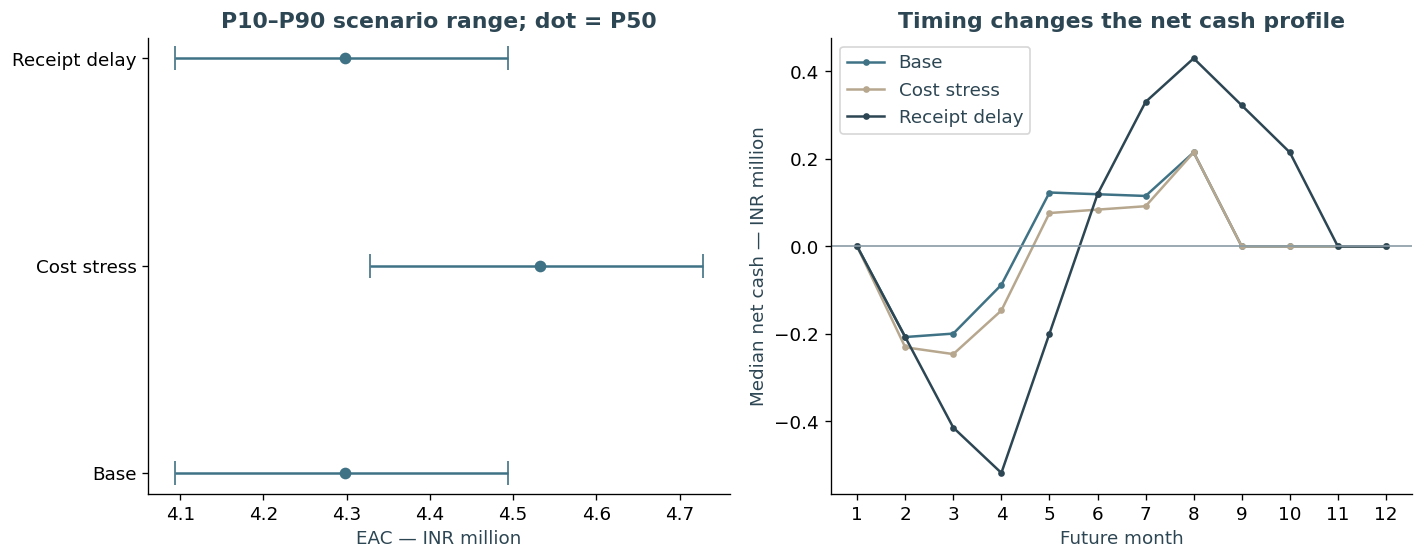

In [5]:
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
for i,(name,r) in enumerate(results.items()):
    lo,mid,hi=np.array(r["eac_p10_p50_p90"])/1e6
    axes[0].errorbar(mid,i,xerr=[[mid-lo],[hi-mid]],fmt="o",capsize=7,color="#3F7285")
    axes[1].plot(range(1,13),np.array(r["monthly_net_cash_p50"])/1e6,marker=".",label=name)
axes[0].set(yticks=range(3),yticklabels=list(results),xlabel="EAC — INR million",title="P10–P90 scenario range; dot = P50")
axes[1].axhline(0,color="#899BA5",linewidth=1)
axes[1].set(title="Timing changes the net cash profile",xlabel="Future month",ylabel="Median net cash — INR million",xticks=range(1,13))
axes[1].legend()
finish(fig,"04-scenarios")

## 4. Sensitivity: which assumption should be challenged first?

Vary one assumption at a time while preserving the same random seed. This isolates
scenario effects; it is not causal inference. Receipt lag should leave EAC unchanged,
while funding changes. I test that invariant below.

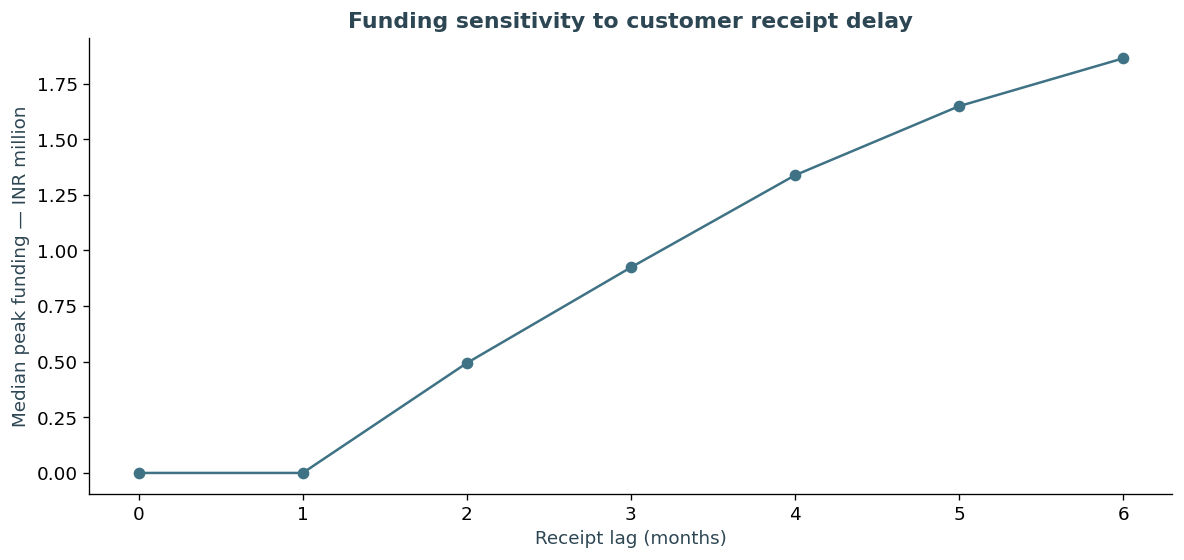

,receipt_lag,funding_p50,eac_p50
0,0,0.00,4298233.37
1,1,-0.00,4298233.37
2,2,494061.15,4298233.37
3,3,923990.67,4298233.37
4,4,1338156.27,4298233.37
5,5,1648780.48,4298233.37
6,6,1863745.24,4298233.37


In [6]:
stress=[]
for lag in range(0,7):
    r=scenario(row.to_dict(),row.original_budget,seed=42,receipt_delay=lag)
    stress.append({"receipt_lag":lag,"funding_p50":r["peak_funding_p10_p50_p90"][1],"eac_p50":r["eac_p10_p50_p90"][1]})
sensitivity=pd.DataFrame(stress)
assert sensitivity.eac_p50.nunique()==1
assert results["Cost stress"]["eac_p10_p50_p90"][1]>results["Base"]["eac_p10_p50_p90"][1]
fig,ax=plt.subplots()
ax.plot(sensitivity.receipt_lag,sensitivity.funding_p50/1e6,marker="o")
ax.set(title="Funding sensitivity to customer receipt delay",xlabel="Receipt lag (months)",ylabel="Median peak funding — INR million",xticks=range(7))
finish(fig,"04-funding-sensitivity")
display(sensitivity.round(2))

## 5. Simulation stability is not model validity

More draws should stabilise a chosen model's quantiles, but cannot validate its assumptions.
Compare P50/P90 across seeds below. This checks Monte Carlo variability only. There is no
empirical cash-flow backtest in this dataset.

In [7]:
stability=[]
for seed in [11,42,73]:
    r=scenario(row.to_dict(),row.original_budget,draws=5000,seed=seed)
    stability.append({"seed":seed,"EAC P50":r["eac_p10_p50_p90"][1],"EAC P90":r["eac_p10_p50_p90"][2]})
display(pd.DataFrame(stability).round(2))

,seed,EAC P50,EAC P90
0,11,4303005.66,4498154.30
1,42,4298233.37,4494116.33
2,73,4301283.68,4502768.96


## 6. Decision and next steps

Use the funding sensitivity to discuss collection terms, payment commitments and available
liquidity; use the cost stress to request a revised quantity/rate forecast. Do not replace the
commercial team's forecast with these assumptions.

Before production: obtain authorised remaining quantities, resource rates, actual payment
schedules, retention/tax treatment and opening cash. Estimate distributions from appropriate
history, backtest and have finance review extreme scenarios. No funding savings are claimed.

**Interview discussion:** Why is this Data Science without training an ML model? Why is P90
not a guarantee? Why can late receipts increase funding need without increasing EAC?